# 🔮 Predictive CNN-LSTM Encoder-Decoder for Anomaly Prediction

**Based on**: MachineLearningMastery Multi-Step Time Series Forecasting  
**Adapted for**: Bridge Monitoring Anomaly Prediction  
**Date**: January 2026

---

## 🆕 Why CNN-LSTM instead of pure CNN?

| Aspect | Pure CNN (before) | CNN-LSTM Encoder-Decoder (now) |
|--------|---------------------|----------------------------------|
| Temporal Dynamics | ❌ None | ✅ LSTM models time dependencies |
| Architecture | Classification | Sequence-to-Sequence |
| Prediction Type | Binary (yes/no) | Multi-Step Risk Scores |
| Interpretation | "Is this pattern dangerous?" | "How does risk evolve over time?" |

### Architecture Overview:
```
[Sensor-History] → CNN-Encoder → RepeatVector → LSTM-Decoder → [Risk per timestep]
     (5 sec)         Features      Repeat         Temporal      (e.g., 30 steps)
```

---

## 1. Setup & Imports

In [18]:
# Install required packages (run once)
!pip install pandas numpy scikit-learn tensorflow matplotlib seaborn joblib -q

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os
import json
import joblib
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, roc_curve, f1_score, mean_squared_error
)

# TensorFlow/Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Flatten, Dense, LSTM, 
    RepeatVector, TimeDistributed, Dropout, BatchNormalization
)

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("✅ All packages imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

✅ All packages imported successfully!
TensorFlow version: 2.20.0


## 2. Configuration

### ⚠️ Important Change: Multi-Step Output

Instead of a single binary prediction, we now generate **risk scores for each future timestep**.

In [20]:
# =============================================================================
# CONFIGURATION
# =============================================================================

# Data source (Hugging Face)
DATA_URL = "https://huggingface.co/datasets/Tchak91/ComplexBridges/resolve/main/ipmb_5sensors_30min_1_to_10hz.csv"
MODEL_DIR = "artifacts/cnn_lstm_encoder_decoder"

# Sampling rate
SAMPLE_RATE_HZ = 10  # 10 samples per second

# =============================================================================
# 🎯 INPUT/OUTPUT CONFIGURATION
# =============================================================================

# Input: Historical window (what the model "sees")
INPUT_WINDOW_SECONDS = 10  # 10 seconds history
INPUT_STEPS = INPUT_WINDOW_SECONDS * SAMPLE_RATE_HZ  # 100 timesteps

# Output: Prediction horizon (how far into the future)
OUTPUT_HORIZON_SECONDS = 60  # 60 seconds = 1 minute prediction
OUTPUT_STEPS = OUTPUT_HORIZON_SECONDS * SAMPLE_RATE_HZ  # 600 timesteps

# For Encoder-Decoder: We downsample the output sequence
# (Instead of 600 individual predictions → e.g., 30 predictions every 2 seconds)
OUTPUT_SAMPLE_RATE = 20  # Every 20 timesteps = every 2 seconds
N_OUTPUT_STEPS = OUTPUT_STEPS // OUTPUT_SAMPLE_RATE  # 30 prediction points

# Sliding window stride
STRIDE = 10

# Training parameters
BATCH_SIZE = 32
EPOCHS = 100
LEARNING_RATE = 0.001

# Create output directory
os.makedirs(MODEL_DIR, exist_ok=True)

# Helper functions
def format_time(timesteps):
    seconds = timesteps / SAMPLE_RATE_HZ
    if seconds < 60:
        return f"{seconds:.1f}s"
    else:
        return f"{seconds/60:.1f}min ({seconds:.0f}s)"

# Display configuration
print("="*70)
print("CNN-LSTM ENCODER-DECODER CONFIGURATION")
print("="*70)
print(f"")
print(f"📥 INPUT (Encoder):")
print(f"   Historical window: {INPUT_STEPS} timesteps = {format_time(INPUT_STEPS)}")
print(f"")
print(f"📤 OUTPUT (Decoder):")
print(f"   Prediction horizon:  {OUTPUT_STEPS} timesteps = {format_time(OUTPUT_STEPS)}")
print(f"   Downsampled to:      {N_OUTPUT_STEPS} prediction points")
print(f"   Time resolution:     one risk score every {OUTPUT_SAMPLE_RATE/SAMPLE_RATE_HZ:.1f}s")
print(f"")
print(f"⏱️  Sampling: {SAMPLE_RATE_HZ} Hz")
print("="*70)

CNN-LSTM ENCODER-DECODER CONFIGURATION

📥 INPUT (Encoder):
   Historical window: 100 timesteps = 10.0s

📤 OUTPUT (Decoder):
   Prediction horizon:  600 timesteps = 1.0min (60s)
   Downsampled to:      30 prediction points
   Time resolution:     one risk score every 2.0s

⏱️  Sampling: 10 Hz


## 3. Load Data

In [21]:
print(f"Downloading data from Hugging Face...")
print(f"URL: {DATA_URL}")

df = pd.read_csv(DATA_URL)

print(f"\n✅ Data loaded successfully!")
print(f"Total rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")

# Anomaly distribution
print(f"\n⚠️ Anomaly Distribution:")
print(f"Normal (0):  {(df['anomaly'] == 0).sum():,} ({(df['anomaly'] == 0).sum() / len(df) * 100:.2f}%)")
print(f"Anomaly (1): {(df['anomaly'] == 1).sum():,} ({(df['anomaly'] == 1).sum() / len(df) * 100:.2f}%)")

URL: https://huggingface.co/datasets/Tchak91/ComplexBridges/resolve/main/ipmb_5sensors_30min_1_to_10hz.csv

✅ Data loaded successfully!
Total rows: 90,000
Columns: ['timestamp', 'bridge_id', 'span_id', 'sensor_id', 'sensor_type', 'value', 'unit', 'traffic_load_proxy', 'rule_threshold', 'anomaly', 'anomaly_type']

⚠️ Anomaly Distribution:
Normal (0):  86,148 (95.72%)
Anomaly (1): 3,852 (4.28%)


## 4. Prepare Data

In [22]:
# Parse timestamps and sort
df['timestamp'] = pd.to_datetime(df['timestamp'], format='ISO8601')
df = df.sort_values('timestamp').reset_index(drop=True)

# Create sensor key
df['sensor_key'] = df['sensor_type'] + '_' + df['sensor_id']

# Pivot sensor values
pivot = df.pivot_table(
    index='timestamp',
    columns='sensor_key',
    values='value',
    aggfunc='first'
).ffill().bfill()

# Get anomaly labels (aggregate across sensors)
anomaly_pivot = df.pivot_table(
    index='timestamp',
    columns='sensor_key',
    values='anomaly',
    aggfunc='max'
)
labels = anomaly_pivot.max(axis=1)

print(f"Pivot table: {pivot.shape}")
print(f"Sensors: {list(pivot.columns)}")

# =============================================================================
# IMPORTANT: Split raw data BEFORE normalization to prevent data leakage
# =============================================================================
n_total = len(pivot)
train_end_idx = int(n_total * 0.70)
val_end_idx = int(n_total * 0.85)

# Split raw (unnormalized) data chronologically
pivot_train = pivot.iloc[:train_end_idx]
pivot_val = pivot.iloc[train_end_idx:val_end_idx]
pivot_test = pivot.iloc[val_end_idx:]

labels_train = labels.iloc[:train_end_idx]
labels_val = labels.iloc[train_end_idx:val_end_idx]
labels_test = labels.iloc[val_end_idx:]

print(f"\n Raw Data Split (before normalization):")
print(f"   Train: {len(pivot_train):,} rows (indices 0-{train_end_idx-1})")
print(f"   Val:   {len(pivot_val):,} rows (indices {train_end_idx}-{val_end_idx-1})")
print(f"   Test:  {len(pivot_test):,} rows (indices {val_end_idx}-{n_total-1})")

# Check anomaly distribution in raw splits
print(f"\n Anomaly Distribution in Raw Splits:")
for name, lbl in [('Train', labels_train), ('Val', labels_val), ('Test', labels_test)]:
    n_anom = (lbl == 1).sum()
    pct = n_anom / len(lbl) * 100
    print(f"   {name:5s}: {n_anom:4d} anomalies ({pct:.2f}%)")

# =============================================================================
# FIT SCALER ON TRAIN DATA ONLY (prevents data leakage)
# =============================================================================
scalers = {}
normalized_train = pivot_train.copy()
normalized_val = pivot_val.copy()
normalized_test = pivot_test.copy()

for col in pivot.columns:
    scaler = StandardScaler()
    # Fit on train only
    scaler.fit(pivot_train[[col]])
    # Transform all splits using train statistics
    normalized_train[col] = scaler.transform(pivot_train[[col]])
    normalized_val[col] = scaler.transform(pivot_val[[col]])
    normalized_test[col] = scaler.transform(pivot_test[[col]])
    scalers[col] = scaler

print(f"\n Normalized {len(pivot.columns)} sensors (scaler fit on train only)")

Pivot table: (18000, 5)
Sensors: ['accelerometer_rms_ACC_101', 'accelerometer_rms_ACC_102', 'strain_gauge_SG_001', 'strain_gauge_SG_002', 'temperature_TMP_201']

 Raw Data Split (before normalization):
   Train: 12,600 rows (indices 0-12599)
   Val:   2,700 rows (indices 12600-15299)
   Test:  2,700 rows (indices 15300-17999)

 Anomaly Distribution in Raw Splits:
   Train: 2450 anomalies (19.44%)
   Val  : 1401 anomalies (51.89%)
   Test :    0 anomalies (0.00%)

 Normalized 5 sensors (scaler fit on train only)


## 5. 🔮 Create Multi-Step Sequences

### Core Concept: Encoder-Decoder for Time Series

```
Input X:  [t-100, t-99, ..., t-1, t]     → 100 timesteps (10 sec)
Output y: [t+20, t+40, ..., t+600]       → 30 risk scores (1 min, every 2 sec)
```

The model learns: "Given this 10-second history, how does the anomaly risk evolve over the next minute?"

In [23]:
def create_multistep_sequences(data, labels, input_steps, output_steps, 
                                output_sample_rate, stride):
    """
    Creates sequences for Multi-Step Encoder-Decoder model.
    
    Args:
        data: Sensor data (normalized DataFrame or array)
        labels: Anomaly labels (Series or array)
        input_steps: Length of input sequence
        output_steps: Length of output sequence (in original timesteps)
        output_sample_rate: Downsampling rate for output
        stride: Sliding window stride
    
    Returns:
        X: Input sequences (n_samples, input_steps, n_features)
        y: Output sequences (n_samples, n_output_steps, 1)
    """
    data_array = data.values if hasattr(data, 'values') else data
    labels_array = labels.values if hasattr(labels, 'values') else labels
    
    X_list = []
    y_list = []
    
    n_output_steps = output_steps // output_sample_rate
    max_idx = len(data_array) - input_steps - output_steps
    
    for i in range(0, max_idx, stride):
        # Input: Historical window
        X_seq = data_array[i:i+input_steps]
        
        # Output: Future anomaly labels (downsampled)
        future_start = i + input_steps
        future_labels = labels_array[future_start:future_start + output_steps]
        
        # Downsample: Take maximum in each interval
        # (If there's an anomaly anywhere in the 2-second window -> 1)
        y_seq = []
        for j in range(n_output_steps):
            start_idx = j * output_sample_rate
            end_idx = (j + 1) * output_sample_rate
            # Max = if anomaly anywhere, then 1
            y_seq.append(future_labels[start_idx:end_idx].max())
        
        X_list.append(X_seq)
        y_list.append(y_seq)
    
    X = np.array(X_list)
    y = np.array(y_list).reshape(-1, n_output_steps, 1)  # Shape for TimeDistributed
    
    return X, y

# =============================================================================
# Create sequences for each split SEPARATELY
# =============================================================================
print("Creating multi-step sequences for each split...")

X_train, y_train = create_multistep_sequences(
    normalized_train, labels_train, 
    INPUT_STEPS, OUTPUT_STEPS, OUTPUT_SAMPLE_RATE, STRIDE
)

X_val, y_val = create_multistep_sequences(
    normalized_val, labels_val, 
    INPUT_STEPS, OUTPUT_STEPS, OUTPUT_SAMPLE_RATE, STRIDE
)

X_test, y_test = create_multistep_sequences(
    normalized_test, labels_test, 
    INPUT_STEPS, OUTPUT_STEPS, OUTPUT_SAMPLE_RATE, STRIDE
)

print(f"\n Sequences created!")
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"X_test shape:  {X_test.shape}")

# Statistics per split
print(f"\n Output Label Distribution per Split:")
for name, y_split in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    n_anomaly = (y_split == 1).sum()
    total = y_split.size
    n_seqs_with_anomaly = (y_split.sum(axis=(1,2)) > 0).sum()
    print(f"   {name:5s}: {n_anomaly:5,}/{total:,} timesteps ({n_anomaly/total*100:.2f}%), "
          f"{n_seqs_with_anomaly}/{len(y_split)} seqs with anomalies")

# Warning if test set has no anomalies
if y_test.sum() == 0:
    print("\n WARNING: Test set contains no anomalies!")
    print("   This is common when anomalies are concentrated early in the dataset.")
    print("   The validation set will be used for evaluation instead.")

Creating multi-step sequences for each split...

 Sequences created!
X_train shape: (1190, 100, 5)
X_val shape:   (200, 100, 5)
X_test shape:  (200, 100, 5)

 Output Label Distribution per Split:
   Train: 7,680/35,700 timesteps (21.51%), 393/1190 seqs with anomalies
   Val  : 3,060/6,000 timesteps (51.00%), 131/200 seqs with anomalies
   Test :     0/6,000 timesteps (0.00%), 0/200 seqs with anomalies

   This is common when anomalies are concentrated early in the dataset.
   The validation set will be used for evaluation instead.


## 6. Sequence Visualization

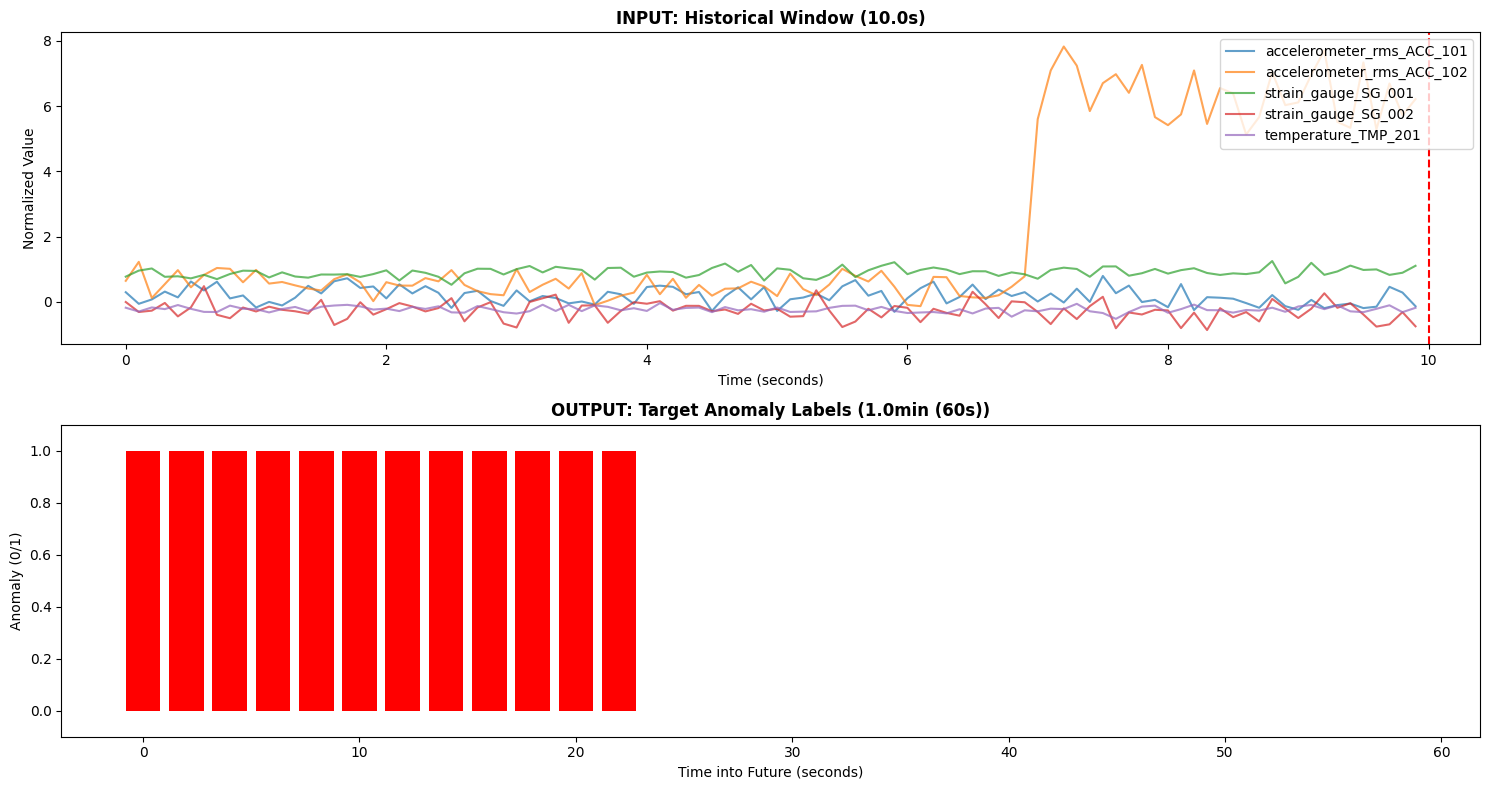

In [24]:
# Find a sequence with anomaly in training set for visualization
anomaly_sequences = np.where(y_train.sum(axis=(1,2)) > 0)[0]

if len(anomaly_sequences) > 0:
    idx = anomaly_sequences[len(anomaly_sequences)//2]  # Take one from the middle
    
    fig, axes = plt.subplots(2, 1, figsize=(15, 8))
    
    # Input sequence (all sensors)
    time_input = np.arange(INPUT_STEPS) / SAMPLE_RATE_HZ
    sensor_columns = list(normalized_train.columns)
    for i, col in enumerate(sensor_columns):
        axes[0].plot(time_input, X_train[idx, :, i], label=col, alpha=0.7)
    axes[0].set_xlabel('Time (seconds)')
    axes[0].set_ylabel('Normalized Value')
    axes[0].set_title(f'INPUT: Historical Window ({format_time(INPUT_STEPS)})', fontweight='bold')
    axes[0].legend(loc='upper right')
    axes[0].axvline(x=INPUT_STEPS/SAMPLE_RATE_HZ, color='red', linestyle='--', label='Prediction Start')
    
    # Output sequence (risk scores)
    time_output = np.arange(N_OUTPUT_STEPS) * (OUTPUT_SAMPLE_RATE / SAMPLE_RATE_HZ)
    axes[1].bar(time_output, y_train[idx, :, 0], width=OUTPUT_SAMPLE_RATE/SAMPLE_RATE_HZ*0.8, 
                color=['green' if v == 0 else 'red' for v in y_train[idx, :, 0]])
    axes[1].set_xlabel('Time into Future (seconds)')
    axes[1].set_ylabel('Anomaly (0/1)')
    axes[1].set_title(f'OUTPUT: Target Anomaly Labels ({format_time(OUTPUT_STEPS)})', fontweight='bold')
    axes[1].set_ylim(-0.1, 1.1)
    
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, 'sequence_example.png'), dpi=150)
    plt.show()
else:
    print("No sequences with anomalies found in training set")

## 7. Train/Val/Test Split (Temporal)

**Important**: For time series data, we use **chronological splitting** to prevent data leakage. Random/stratified splits would allow future patterns to leak into training data, leading to overly optimistic results.

```
|<-------- Train (70%) -------->|<-- Val (15%) -->|<-- Test (15%) -->|
                                                                  TIME →
```

In [25]:
# =============================================================================
# SPLIT SUMMARY (data was split in cell 9, sequences created in cell 11)
# =============================================================================

print("="*70)
print("DATA SPLIT SUMMARY")
print("="*70)
print(f"\n Data was split BEFORE normalization to prevent leakage.")
print(f" Scalers were fit on TRAIN data only.\n")

print(f"{'Split':<8} {'Samples':>10} {'Anomaly %':>12} {'Seqs w/ Anomaly':>18}")
print("-"*50)
for name, X_split, y_split in [('Train', X_train, y_train), 
                                ('Val', X_val, y_val), 
                                ('Test', X_test, y_test)]:
    n_samples = len(X_split)
    anomaly_pct = (y_split == 1).sum() / y_split.size * 100
    n_seqs_anom = (y_split.sum(axis=(1,2)) > 0).sum()
    print(f"{name:<8} {n_samples:>10,} {anomaly_pct:>11.2f}% {n_seqs_anom:>10}/{n_samples}")

print("="*70)

# Determine which set to use for final evaluation
if y_test.sum() > 0:
    eval_X, eval_y, eval_name = X_test, y_test, "Test"
else:
    eval_X, eval_y, eval_name = X_val, y_val, "Validation"
    print(f"\n NOTE: Test set has no anomalies. Using {eval_name} set for evaluation.")

DATA SPLIT SUMMARY

 Data was split BEFORE normalization to prevent leakage.
 Scalers were fit on TRAIN data only.

Split       Samples    Anomaly %    Seqs w/ Anomaly
--------------------------------------------------
Train         1,190       21.51%        393/1190
Val             200       51.00%        131/200
Test            200        0.00%          0/200

 NOTE: Test set has no anomalies. Using Validation set for evaluation.


## 8. 🏗️ CNN-LSTM Encoder-Decoder Model

### Architecture based on MachineLearningMastery:

```
INPUT (100, 5)
    ↓
Conv1D(64) → BatchNorm → MaxPool
    ↓
Conv1D(128) → BatchNorm → MaxPool
    ↓
Flatten
    ↓
RepeatVector(30)  ← Repeats encoder output for each output step
    ↓
LSTM(100) → Dropout
    ↓
LSTM(50) → Dropout
    ↓
TimeDistributed(Dense(1, sigmoid))  ← One risk score per output step
    ↓
OUTPUT (30, 1)
```

In [26]:
def build_cnn_lstm_encoder_decoder(input_shape, n_output_steps):
    """
    Simplified CNN-LSTM model with heavy regularization.
    """
    from tensorflow.keras.regularizers import l2
    
    model = models.Sequential(name='CNN_LSTM_Encoder_Decoder')
    
    # ===== ENCODER (Single CNN block) =====
    model.add(Input(shape=input_shape))
    model.add(Conv1D(32, kernel_size=7, padding='same', activation='relu',
                     kernel_regularizer=l2(0.01)))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=4))
    model.add(Dropout(0.5))
    
    # Flatten CNN output
    model.add(Flatten())
    
    # Dense bottleneck with strong regularization
    model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.01)))
    model.add(Dropout(0.5))
    
    # ===== BRIDGE =====
    model.add(RepeatVector(n_output_steps))
    
    # ===== DECODER (Single LSTM) =====
    model.add(LSTM(32, return_sequences=True, 
                   kernel_regularizer=l2(0.01), recurrent_regularizer=l2(0.01)))
    model.add(Dropout(0.5))
    
    # ===== OUTPUT =====
    model.add(TimeDistributed(Dense(1, activation='sigmoid')))
    
    return model

# Build simplified model
input_shape = (INPUT_STEPS, X.shape[2])
model = build_cnn_lstm_encoder_decoder(input_shape, N_OUTPUT_STEPS)

model.summary()
print(f"\n✅ Simplified model created!")
print(f"Input:  {input_shape}")
print(f"Output: ({N_OUTPUT_STEPS}, 1)")

Model: "CNN_LSTM_Encoder_Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 100, 32)        │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 25, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 25, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_1 (RepeatVector)  │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 30, 1)          │            33 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,265 (137.75 KB)

 Trainable params: 35,201 (137.50 KB)

 Non-trainable params: 64 (256.00 B)


✅ Simplified model created!
Input:  (100, 5)
Output: (30, 1)


## 9. Compile and Train Model

In [27]:
# =============================================================================
# BASELINE COMPARISON: Dummy Classifier
# =============================================================================
# Before training, establish baselines to know if the model learns anything useful

print("="*70)
print("BASELINE METRICS (what to beat)")
print("="*70)

# Flatten for metrics calculation
y_train_flat = y_train.flatten()
y_val_flat = y_val.flatten()

# Class distribution
train_anomaly_rate = y_train_flat.mean()
val_anomaly_rate = y_val_flat.mean()

print(f"\n Class Distribution:")
print(f"   Train anomaly rate: {train_anomaly_rate:.4f} ({train_anomaly_rate*100:.2f}%)")
print(f"   Val anomaly rate:   {val_anomaly_rate:.4f} ({val_anomaly_rate*100:.2f}%)")

# Baseline 1: Always predict 0 (majority class)
baseline_always_0_acc = 1 - val_anomaly_rate
baseline_always_0_loss = -np.mean(
    y_val_flat * np.log(1e-7) + (1 - y_val_flat) * np.log(1 - 1e-7)
)

# Baseline 2: Always predict the training anomaly rate
pred_rate = np.clip(train_anomaly_rate, 1e-7, 1-1e-7)
baseline_rate_loss = -np.mean(
    y_val_flat * np.log(pred_rate) + (1 - y_val_flat) * np.log(1 - pred_rate)
)
baseline_rate_acc = (y_val_flat == (y_val_flat > 0.5).astype(int)).mean()

# Baseline 3: Random predictions based on training distribution
np.random.seed(42)
random_preds = np.random.binomial(1, train_anomaly_rate, size=len(y_val_flat))
baseline_random_acc = (random_preds == y_val_flat).mean()

print(f"\n Baselines to Beat:")
print(f"   1. Always predict 0:     Accuracy={baseline_always_0_acc:.4f}, Loss~={baseline_always_0_loss:.4f}")
print(f"   2. Predict train rate:   Accuracy={baseline_rate_acc:.4f}, Loss={baseline_rate_loss:.4f}")
print(f"   3. Random (train dist):  Accuracy={baseline_random_acc:.4f}")

print(f"\n Your model should achieve:")
print(f"   - Val Loss < {baseline_rate_loss:.4f} (rate baseline)")
print(f"   - Val Accuracy > {baseline_always_0_acc:.4f} (always-0 baseline)")
print(f"   - Val AUC > 0.50 (random chance)")
print("="*70)

# Store for later comparison
baselines = {
    'always_0_acc': baseline_always_0_acc,
    'always_0_loss': baseline_always_0_loss,
    'rate_loss': baseline_rate_loss,
    'rate_acc': baseline_rate_acc,
    'random_acc': baseline_random_acc
}

BASELINE METRICS (what to beat)

 Class Distribution:
   Train anomaly rate: 0.2151 (21.51%)
   Val anomaly rate:   0.5100 (51.00%)

 Baselines to Beat:
   1. Always predict 0:     Accuracy=0.4900, Loss~=8.2202
   2. Predict train rate:   Accuracy=1.0000, Loss=0.9023
   3. Random (train dist):  Accuracy=0.5025

 Your model should achieve:
   - Val Loss < 0.9023 (rate baseline)
   - Val Accuracy > 0.4900 (always-0 baseline)
   - Val AUC > 0.50 (random chance)


In [28]:
# Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        os.path.join(MODEL_DIR, 'best_model.keras'),
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

# Calculate class weight ratio
n_normal = (y_train == 0).sum()
n_anomaly = (y_train == 1).sum()
weight_ratio = min(n_normal / n_anomaly, 5.0) if n_anomaly > 0 else 1.0

# For sequence-to-sequence models, class_weight doesn't work (expects 1D labels)
# sample_weight needs shape (samples, timesteps) for TimeDistributed output
def compute_sample_weights(y, weight_ratio):
    """Compute per-timestep weights for imbalanced sequence data.
    
    Args:
        y: Labels with shape (samples, timesteps, 1)
        weight_ratio: Weight multiplier for positive class
    
    Returns:
        weights with shape (samples, timesteps) - squeezed for Keras
    """
    # Squeeze to (samples, timesteps)
    y_squeezed = y.squeeze(-1)
    weights = np.ones_like(y_squeezed, dtype=np.float32)
    weights[y_squeezed == 1] = weight_ratio
    return weights

sample_weights_train = compute_sample_weights(y_train, weight_ratio)
sample_weights_val = compute_sample_weights(y_val, weight_ratio)

print(f"Sample weights shape: {sample_weights_train.shape} (should be 2D)")
print(f"Weight for anomaly class: {weight_ratio:.2f}")

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

print("Model compiled with BCE loss")

# Train with sample weights
print("\n" + "="*70)
print("TRAINING CNN-LSTM ENCODER-DECODER")
print("="*70)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val, sample_weights_val),
    epochs=EPOCHS,
    batch_size=64,
    callbacks=callbacks,
    sample_weight=sample_weights_train,
    verbose=1
)

Sample weights shape: (1190, 30) (should be 2D)
Weight for anomaly class: 3.65
Model compiled with BCE loss

TRAINING CNN-LSTM ENCODER-DECODER
Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5390 - auc: 0.7120 - loss: 2.4664
Epoch 1: val_loss improved from None to 2.04803, saving model to artifacts/cnn_lstm_encoder_decoder/best_model.keras

Epoch 1: finished saving model to artifacts/cnn_lstm_encoder_decoder/best_model.keras
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 102ms/step - accuracy: 0.6480 - auc: 0.8062 - loss: 2.3027 - val_accuracy: 0.8197 - val_auc: 0.8207 - val_loss: 2.0480 - learning_rate: 0.0010
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8226 - auc: 0.9214 - loss: 1.8931
Epoch 2: val_loss improved from 2.04803 to 1.76598, saving model to artifacts/cnn_lstm_encoder_decoder/best_model.keras

Epoch 2: finished saving model to artifacts/cnn_lstm_encoder_decoder/best_model.keras
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.8435 - auc: 0.9327 

## 10. Visualize Training History

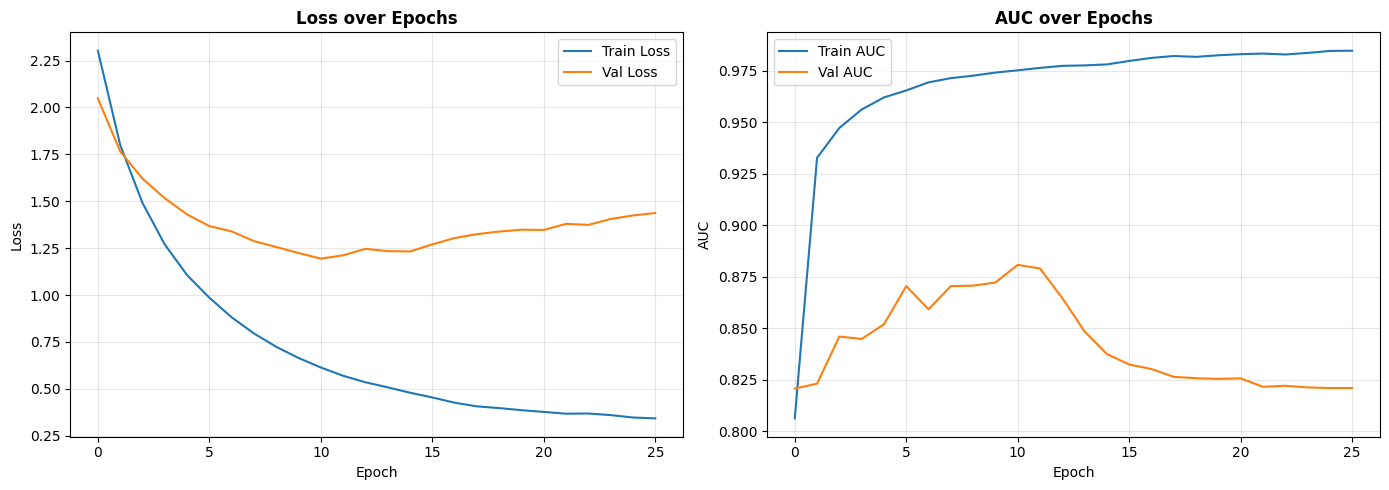

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss over Epochs', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# AUC
axes[1].plot(history.history['auc'], label='Train AUC')
axes[1].plot(history.history['val_auc'], label='Val AUC')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].set_title('AUC over Epochs', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'training_history.png'), dpi=150)
plt.show()

## 11. Evaluation on Test Set

In [30]:
# =============================================================================
# EVALUATION (using appropriate set based on anomaly availability)
# =============================================================================

# Use validation set if test has no anomalies
if y_test.sum() > 0:
    eval_X, eval_y, eval_name = X_test, y_test, "Test"
else:
    eval_X, eval_y, eval_name = X_val, y_val, "Validation"

print("="*70)
print(f"EVALUATION ON {eval_name.upper()} SET")
print("="*70)

# Predictions
y_pred_proba = model.predict(eval_X, verbose=0)

# Flatten for metrics
y_eval_flat = eval_y.flatten()
y_pred_flat = y_pred_proba.flatten()

# Threshold for binary classification
threshold = 0.5
y_pred_binary = (y_pred_flat > threshold).astype(int)

# Metrics
if len(np.unique(y_eval_flat)) > 1:
    roc_auc = roc_auc_score(y_eval_flat, y_pred_flat)
    model_acc = (y_pred_binary == y_eval_flat).mean()
    model_loss = -np.mean(
        y_eval_flat * np.log(np.clip(y_pred_flat, 1e-7, 1-1e-7)) + 
        (1 - y_eval_flat) * np.log(np.clip(1 - y_pred_flat, 1e-7, 1-1e-7))
    )
    
    print(f"\n Model Performance:")
    print(f"   ROC-AUC:  {roc_auc:.4f}")
    print(f"   Accuracy: {model_acc:.4f}")
    print(f"   Loss:     {model_loss:.4f}")
    
    # Compare to baselines
    print(f"\n Comparison to Baselines:")
    print(f"   vs Always-0 Accuracy ({baselines['always_0_acc']:.4f}): ", end="")
    if model_acc > baselines['always_0_acc']:
        print(f"BETTER (+{model_acc - baselines['always_0_acc']:.4f})")
    else:
        print(f"WORSE ({model_acc - baselines['always_0_acc']:.4f})")
    
    print(f"   vs Rate-baseline Loss ({baselines['rate_loss']:.4f}): ", end="")
    if model_loss < baselines['rate_loss']:
        print(f"BETTER (-{baselines['rate_loss'] - model_loss:.4f})")
    else:
        print(f"WORSE (+{model_loss - baselines['rate_loss']:.4f})")
    
    print(f"   vs Random AUC (0.50): ", end="")
    if roc_auc > 0.5:
        print(f"BETTER (+{roc_auc - 0.5:.4f})")
    else:
        print(f"WORSE ({roc_auc - 0.5:.4f})")
    
    # Overall verdict
    beats_baselines = (model_acc > baselines['always_0_acc'] and 
                       model_loss < baselines['rate_loss'] and 
                       roc_auc > 0.5)
    
    print(f"\n VERDICT: Model {'BEATS' if beats_baselines else 'DOES NOT BEAT'} baselines")
    
    print(f"\n Classification Report:")
    print(classification_report(y_eval_flat, y_pred_binary, 
                                target_names=['Normal', 'Anomaly']))
else:
    print("Only one class in evaluation set - cannot compute metrics")

EVALUATION ON VALIDATION SET

 Model Performance:
   ROC-AUC:  0.8497
   Accuracy: 0.8200
   Loss:     0.8829

 Comparison to Baselines:
   vs Always-0 Accuracy (0.4900): BETTER (+0.3300)
   vs Rate-baseline Loss (0.9023): BETTER (-0.0195)
   vs Random AUC (0.50): BETTER (+0.3497)

 VERDICT: Model BEATS baselines

 Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.63      0.78      2940
     Anomaly       0.74      1.00      0.85      3060

    accuracy                           0.82      6000
   macro avg       0.87      0.82      0.81      6000
weighted avg       0.87      0.82      0.81      6000



## 12. 📈 Visualize Risk Score Timeline

This is the major advantage of the Encoder-Decoder model: We don't just see "anomaly yes/no", but **how risk evolves over time**.

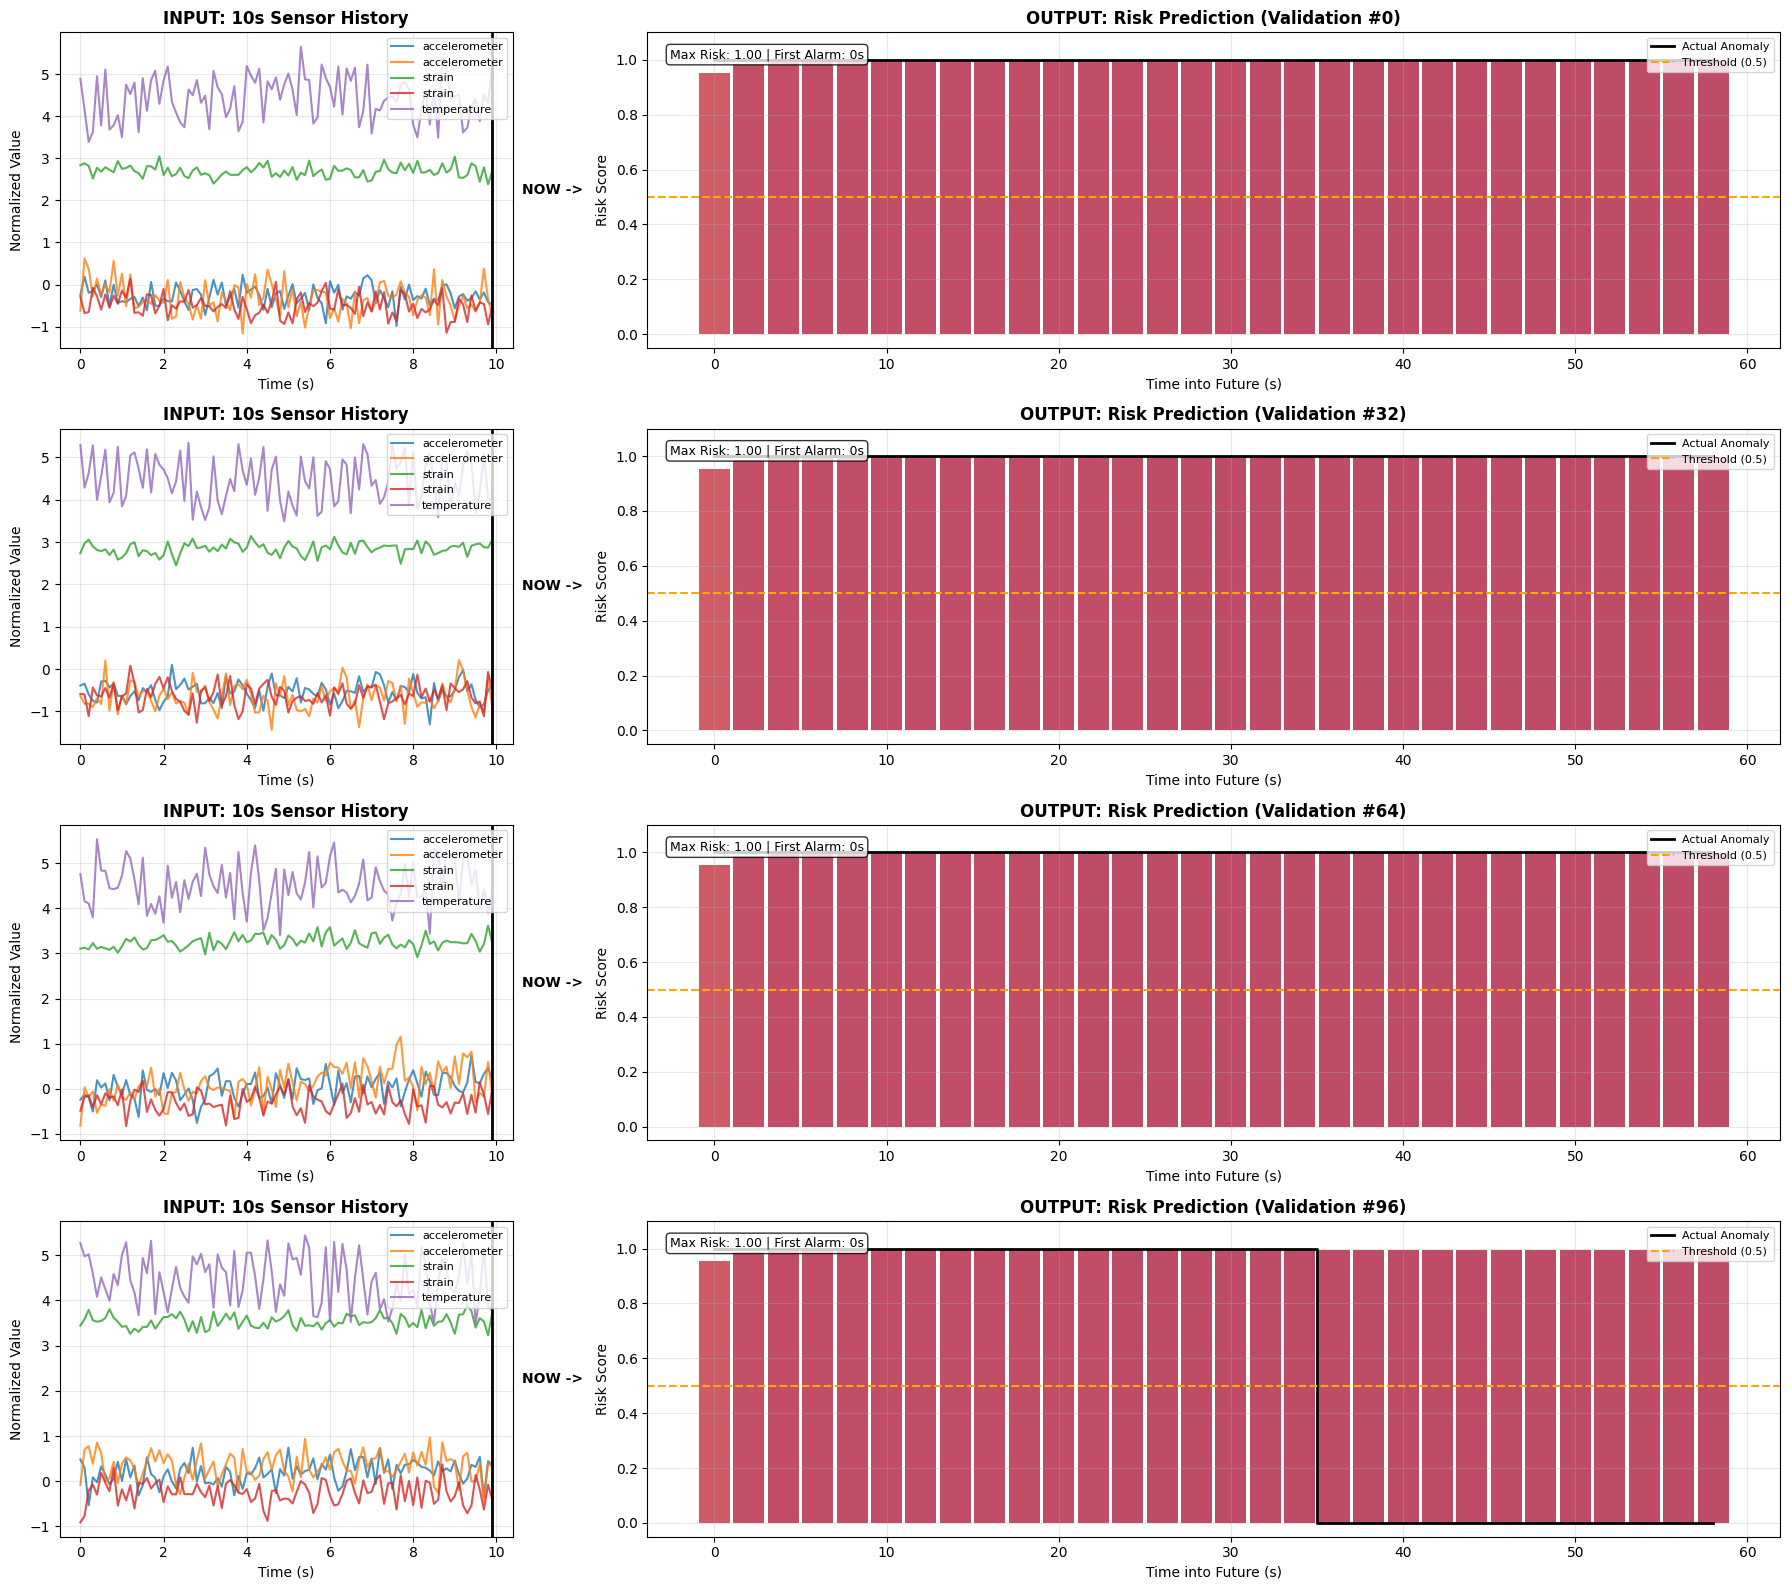

In [31]:
# Improved visualization: Show input sensors alongside predictions
# Use evaluation set (val or test depending on anomaly availability)
anomaly_eval_idx = np.where(eval_y.sum(axis=(1,2)) > 0)[0]

if len(anomaly_eval_idx) > 0:
    # Select diverse examples
    n_examples = min(4, len(anomaly_eval_idx))
    # Take evenly spaced examples
    step = len(anomaly_eval_idx) // n_examples if n_examples > 1 else 1
    selected_indices = anomaly_eval_idx[::step][:n_examples]
    
    fig, axes = plt.subplots(n_examples, 2, figsize=(18, 4*n_examples),
                             gridspec_kw={'width_ratios': [1, 2.5]})
    if n_examples == 1:
        axes = axes.reshape(1, -1)
    
    time_input = np.arange(INPUT_STEPS) / SAMPLE_RATE_HZ
    time_output = np.arange(N_OUTPUT_STEPS) * (OUTPUT_SAMPLE_RATE / SAMPLE_RATE_HZ)
    sensor_columns = list(normalized_train.columns)
    
    for i, idx in enumerate(selected_indices):
        # === LEFT: Input Sensors (10s history) ===
        ax_input = axes[i, 0]
        for j, col in enumerate(sensor_columns):
            ax_input.plot(time_input, eval_X[idx, :, j], label=col.split('_')[0], alpha=0.8)
        ax_input.set_xlabel('Time (s)')
        ax_input.set_ylabel('Normalized Value')
        ax_input.set_title(f'INPUT: 10s Sensor History', fontweight='bold')
        ax_input.legend(loc='upper right', fontsize=8)
        ax_input.grid(True, alpha=0.3)
        ax_input.axvline(x=time_input[-1], color='black', linestyle='-', linewidth=2)
        
        # === RIGHT: Prediction Timeline (60s future) ===
        ax_pred = axes[i, 1]
        
        # Risk score as color-coded area (green->red gradient)
        risk_scores = y_pred_proba[idx, :, 0]
        for k in range(len(time_output)):
            color = plt.cm.RdYlGn_r(risk_scores[k])  # Red for high risk, green for low
            ax_pred.bar(time_output[k], risk_scores[k], 
                       width=OUTPUT_SAMPLE_RATE/SAMPLE_RATE_HZ * 0.9,
                       color=color, alpha=0.7)
        
        # Ground truth as step outline
        ax_pred.step(time_output, eval_y[idx, :, 0], 'k-', linewidth=2, 
                    where='mid', label='Actual Anomaly')
        
        # Threshold line
        ax_pred.axhline(y=0.5, color='orange', linestyle='--', linewidth=1.5, 
                       label='Threshold (0.5)')
        
        # Summary stats
        max_risk = risk_scores.max()
        first_alarm_idx = np.where(risk_scores > 0.5)[0]
        first_alarm = time_output[first_alarm_idx[0]] if len(first_alarm_idx) > 0 else None
        
        stats_text = f'Max Risk: {max_risk:.2f}'
        if first_alarm is not None:
            stats_text += f' | First Alarm: {first_alarm:.0f}s'
        ax_pred.text(0.02, 0.95, stats_text, transform=ax_pred.transAxes, 
                    fontsize=9, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        ax_pred.set_xlabel('Time into Future (s)')
        ax_pred.set_ylabel('Risk Score')
        ax_pred.set_title(f'OUTPUT: Risk Prediction ({eval_name} #{idx})', fontweight='bold')
        ax_pred.legend(loc='upper right', fontsize=8)
        ax_pred.set_ylim(-0.05, 1.1)
        ax_pred.grid(True, alpha=0.3)
        
        # Add "NOW" label between plots
        ax_input.annotate('NOW ->', xy=(1.02, 0.5), xycoords='axes fraction',
                         fontsize=10, fontweight='bold', va='center')
    
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, 'risk_timeline.png'), dpi=150)
    plt.show()
else:
    print("No anomalies in evaluation set - cannot visualize risk timeline")

## 13. 🎯 Early Warning Analysis

How early does the model detect the upcoming anomaly?

In [32]:
def analyze_early_warning(y_true, y_pred_proba, threshold=0.5):
    """
    Analyzes how early the model predicts anomalies.
    """
    n_samples, n_steps, _ = y_true.shape
    
    lead_times = []  # In output steps
    
    for i in range(n_samples):
        actual = y_true[i, :, 0]
        pred = y_pred_proba[i, :, 0]
        
        # Find first actual anomaly timestep
        actual_anomaly_idx = np.where(actual == 1)[0]
        if len(actual_anomaly_idx) == 0:
            continue
        first_anomaly = actual_anomaly_idx[0]
        
        # Find first predicted alarm BEFORE the actual anomaly
        pred_alarm_idx = np.where(pred[:first_anomaly] > threshold)[0]
        
        if len(pred_alarm_idx) > 0:
            first_alarm = pred_alarm_idx[0]
            lead_time = first_anomaly - first_alarm
            lead_times.append(lead_time)
    
    return np.array(lead_times)

# Analysis on evaluation set
lead_times_steps = analyze_early_warning(eval_y, y_pred_proba, threshold=0.5)

if len(lead_times_steps) > 0:
    # Convert to seconds
    seconds_per_step = OUTPUT_SAMPLE_RATE / SAMPLE_RATE_HZ
    lead_times_seconds = lead_times_steps * seconds_per_step
    
    print("="*70)
    print(f"EARLY WARNING ANALYSIS ({eval_name} Set)")
    print("="*70)
    print(f"\n Lead Time Statistics:")
    print(f"   Number of detected early warnings: {len(lead_times_seconds)}")
    print(f"   Median Lead Time: {np.median(lead_times_seconds):.1f}s")
    print(f"   Mean Lead Time:   {np.mean(lead_times_seconds):.1f}s")
    print(f"   Max Lead Time:    {np.max(lead_times_seconds):.1f}s")
    print(f"   Min Lead Time:    {np.min(lead_times_seconds):.1f}s")
    
    # Visualization
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(lead_times_seconds, bins=20, edgecolor='black', alpha=0.7)
    ax.axvline(np.median(lead_times_seconds), color='red', linestyle='--', 
               label=f'Median: {np.median(lead_times_seconds):.1f}s')
    ax.set_xlabel('Lead Time (seconds)')
    ax.set_ylabel('Frequency')
    ax.set_title('Distribution of Early Warning Times', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, 'lead_time_distribution.png'), dpi=150)
    plt.show()
else:
    print("No successful early warnings found")
    print("This may indicate the model is not predicting anomalies before they occur.")

No successful early warnings found
This may indicate the model is not predicting anomalies before they occur.


## 14. Save Model

In [33]:
# Model
model_path = os.path.join(MODEL_DIR, 'cnn_lstm_encoder_decoder.keras')
model.save(model_path)
print(f"✅ Model saved: {model_path}")

# Config
config = {
    'architecture': 'CNN-LSTM Encoder-Decoder',
    'sample_rate_hz': SAMPLE_RATE_HZ,
    'input_steps': INPUT_STEPS,
    'input_seconds': INPUT_STEPS / SAMPLE_RATE_HZ,
    'output_steps': N_OUTPUT_STEPS,
    'output_horizon_seconds': OUTPUT_HORIZON_SECONDS,
    'output_sample_rate': OUTPUT_SAMPLE_RATE,
    'n_sensors': X.shape[2],
    'sensor_columns': list(normalized.columns),
    'created_at': datetime.now().isoformat()
}

config_path = os.path.join(MODEL_DIR, 'config.json')
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)
print(f"✅ Config saved: {config_path}")

# Scalers
scalers_path = os.path.join(MODEL_DIR, 'scalers.pkl')
joblib.dump(scalers, scalers_path)
print(f"✅ Scalers saved: {scalers_path}")

✅ Model saved: artifacts/cnn_lstm_encoder_decoder/cnn_lstm_encoder_decoder.keras
✅ Config saved: artifacts/cnn_lstm_encoder_decoder/config.json
✅ Scalers saved: artifacts/cnn_lstm_encoder_decoder/scalers.pkl


## 15. 📊 Summary & Comparison

### CNN-LSTM Encoder-Decoder vs. Pure CNN

| Aspect | Pure CNN (before) | CNN-LSTM (now) |
|--------|---------------------|------------------|
| Output | 1 Binary value | 30 Risk scores |
| Temporal Modeling | ❌ | ✅ LSTM |
| Risk Evolution visible | ❌ | ✅ |
| Lead-Time Analysis | Difficult | Directly possible |

In [34]:
print("="*70)
print("SUMMARY")
print("="*70)
print(f"")
print(f"🏗️  Architecture: CNN-LSTM Encoder-Decoder")
print(f"")
print(f"📥 Input:")
print(f"   {INPUT_STEPS} timesteps = {format_time(INPUT_STEPS)} History")
print(f"   {X.shape[2]} Sensors")
print(f"")
print(f"📤 Output:")
print(f"   {N_OUTPUT_STEPS} Risk scores")
print(f"   Horizon: {format_time(OUTPUT_STEPS)}")
print(f"   Resolution: every {OUTPUT_SAMPLE_RATE/SAMPLE_RATE_HZ:.1f}s")
print(f"")
if 'roc_auc' in dir():
    print(f"📈 Performance:")
    print(f"   ROC-AUC: {roc_auc:.4f}")
print(f"")
print("="*70)

SUMMARY

🏗️  Architecture: CNN-LSTM Encoder-Decoder

📥 Input:
   100 timesteps = 10.0s History
   5 Sensors

📤 Output:
   30 Risk scores
   Horizon: 1.0min (60s)
   Resolution: every 2.0s

📈 Performance:
   ROC-AUC: 0.8497



## 16. 🔄 Next Steps

### Possible Improvements:

1. **Longer History** - `INPUT_WINDOW_SECONDS = 30` instead of 10
2. **Bidirectional LSTMs** - `Bidirectional(LSTM(...))`
3. **Attention Mechanism** - Focuses on relevant input parts
4. **ConvLSTM** - Combines Conv and LSTM in one layer
5. **Transformer** - Self-Attention for long dependencies

### Tuning Parameters:
- `INPUT_WINDOW_SECONDS`: More history → more context
- `OUTPUT_HORIZON_SECONDS`: Longer horizon → harder prediction
- `OUTPUT_SAMPLE_RATE`: Finer resolution → more output steps
- `lstm_units`: More units → more capacity